In [1]:
import pandas as pd

df = pd.read_csv("dataset_balanced.csv")

df.head()

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,Label
0,4.043668,212.183578,3.214903,13,0,13,53248,ATTACK
1,0.113059,32558.140517,79.604256,9,1,9,65535,NORMAL
2,0.177058,5546.190842,50.830670,9,0,9,615,ATTACK
3,3.530323,78.179815,1.133041,4,0,4,53248,ATTACK
4,4.855382,299.049593,4.531054,22,0,22,53248,ATTACK


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Label"] = le.fit_transform(df["Label"])

print(le.classes_)

['ATTACK' 'NORMAL']


In [3]:
X = df.drop("Label", axis=1)

y = df["Label"]

print(X.shape)

print(y.shape)

(4656, 7)
(4656,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [5]:
print(X_train.shape)
print(X_test.shape)

print()

print(y_train.value_counts())

print()

print(y_test.value_counts())

(3724, 7)
(932, 7)

Label
0    1862
1    1862
Name: count, dtype: int64

Label
0    466
1    466
Name: count, dtype: int64


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    random_state=42,

    n_estimators=100
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [7]:
y_pred = rf.predict(X_test)

In [8]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report
)

print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision :", precision_score(y_test,y_pred))

print("Recall :", recall_score(y_test,y_pred))

print("F1 :", f1_score(y_test,y_pred))

print()

print(classification_report(y_test,y_pred))

Accuracy : 0.9817596566523605
Precision : 0.9766454352441614
Recall : 0.9871244635193133
F1 : 0.9818569903948773

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       466
           1       0.98      0.99      0.98       466

    accuracy                           0.98       932
   macro avg       0.98      0.98      0.98       932
weighted avg       0.98      0.98      0.98       932



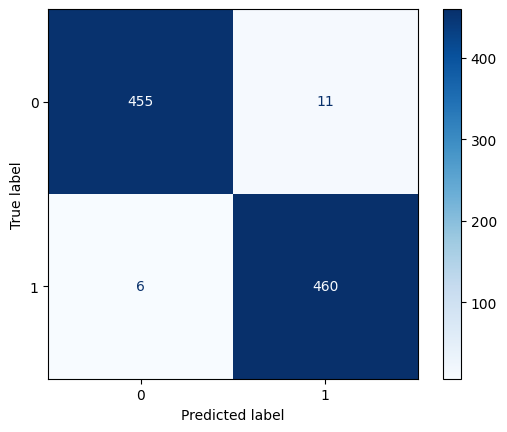

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(

    rf,

    X_test,

    y_test,

    cmap="Blues"
)

plt.show()